# Inspect SAE features

Encode saved planner activations with a trained Top-K SAE, measure SAE health, rank learned features, and inspect the scenes and scenario types that activate each feature. Set `MODEL_LABEL`, run all cells, then call `inspect_feature(feature_id)`. Feature activation here means the post-ReLU, post-Top-K latent value used by the decoder.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

pd.set_option('display.max_colwidth', 80)
plt.style.use('seaborn-v0_8-whitegrid')

# Available: t=0.1, t=0.2, t=0.4, t=0.5, t=0.6, t=0.8
MODEL_LABEL = 't=0.8'
TOP_FEATURES = 30
TOP_SCENES = 15
BATCH_SIZE = 128

cwd = Path.cwd().resolve()
workspace = cwd.parent if cwd.name == 'Project' else cwd
MODEL_SPECS = {
    't=0.1': (workspace / 'sae_output/ae_final_t1.pt', workspace / 'activations_by_t/t_0.1'),
    't=0.2': (workspace / 'sae_output/ae_final_t2.pt', workspace / 'activations_by_t/t_0.2'),
    't=0.4': (workspace / 'sae_output/ae_final.pt', workspace / 'activations_by_t/t_0.4'),
    't=0.5': (workspace / 'Project/sae_output/ae_final.pt', workspace / 'activation_pt_files'),
    't=0.6': (workspace / 'sae_output/ae_final_t6.pt', workspace / 'activations_by_t/t_0.6'),
    't=0.8': (workspace / 'sae_output/ae_final_t8.pt', workspace / 'activations_by_t/t_0.8'),
}
if MODEL_LABEL not in MODEL_SPECS:
    raise ValueError(f'Unknown MODEL_LABEL={MODEL_LABEL!r}; choose from {list(MODEL_SPECS)}')
model_path, activation_dir = MODEL_SPECS[MODEL_LABEL]
for path in (model_path, activation_dir):
    if not path.exists():
        raise FileNotFoundError(path)
print(f'Inspecting {MODEL_LABEL}: {model_path.name} with {activation_dir}')

Inspecting t=0.8: ae_final_t8.pt with /data/saba/parnia/activations_by_t/t_0.8


In [3]:
def load_inputs(data_dir):
    files = sorted(data_dir.glob('*.pt'))
    if not files:
        raise FileNotFoundError(f'No .pt files in {data_dir}')
    vectors, rows = [], []
    for path in files:
        record = torch.load(path, map_location='cpu', weights_only=False)
        info = record.get('scenario_info') or {}
        vectors.append(record['activation'].detach().float().reshape(-1))
        rows.append({
            'row': len(rows), 'file': path.name,
            'simulation_id': record.get('simulation_id', path.stem),
            'scene': info.get('scenario_name') or info.get('token') or record.get('simulation_id', path.stem),
            'scene_type': info.get('scenario_type', 'unknown'),
            'log_name': info.get('log_name', 'unknown'),
            'map_name': info.get('map_name', 'unknown'),
            'target_t': record.get('target_t', np.nan),
            'actual_t': record.get('actual_t', np.nan),
        })
    return torch.stack(vectors), pd.DataFrame(rows)

def load_sae(path, input_dim):
    state = torch.load(path, map_location='cpu', weights_only=True)
    required = {'encoder.weight', 'encoder.bias', 'decoder.weight', 'b_dec', 'k'}
    missing = required.difference(state)
    if missing:
        raise KeyError(f'{path} is missing: {sorted(missing)}')
    if state['encoder.weight'].shape[1] != input_dim:
        raise ValueError(f"Input width {input_dim} != SAE width {state['encoder.weight'].shape[1]}")
    return {k: v.detach().float() for k, v in state.items() if torch.is_tensor(v)}

@torch.inference_mode()
def encode_topk(inputs, state, batch_size=128):
    chunks = []
    k = int(state['k'].item())
    for start in range(0, len(inputs), batch_size):
        x = inputs[start:start + batch_size]
        pre = torch.relu((x - state['b_dec']) @ state['encoder.weight'].T + state['encoder.bias'])
        values, indices = pre.topk(k, dim=1)
        chunks.append(torch.zeros_like(pre).scatter_(1, indices, values))
    return torch.cat(chunks)

inputs, metadata = load_inputs(activation_dir)
sae = load_sae(model_path, inputs.shape[1])
feature_acts = encode_topk(inputs, sae, BATCH_SIZE)
print(f'{len(inputs):,} scenes | input dim {inputs.shape[1]:,} | dictionary size {feature_acts.shape[1]:,} | k={int(sae["k"].item())}')

1,000 scenes | input dim 192 | dictionary size 1,536 | k=5


## SAE health and reconstruction

Dead features never win Top-K on this dataset. Density is the fraction of scenes where a feature wins and is positive. Explained variance closer to 1 is better.

In [4]:
@torch.inference_mode()
def reconstruction_metrics(inputs, features, state):
    reconstruction = features @ state['decoder.weight'].T + state['b_dec']
    mse = (inputs - reconstruction).square().mean().item()
    baseline_mse = (inputs - inputs.mean(dim=0)).square().mean().item()
    return {'MSE': mse, 'RMSE': mse ** 0.5,
            'explained_variance': 1 - mse / baseline_mse if baseline_mse else np.nan,
            'mean_cosine_similarity': torch.nn.functional.cosine_similarity(inputs, reconstruction, dim=1).mean().item()}

active_mask = feature_acts > 0
feature_summary = pd.DataFrame({
    'feature': np.arange(feature_acts.shape[1]),
    'density': active_mask.float().mean(dim=0).numpy(),
    'firing_count': active_mask.sum(dim=0).numpy(),
    'mean_when_active': (feature_acts.sum(dim=0) / active_mask.sum(dim=0).clamp_min(1)).numpy(),
    'peak': feature_acts.max(dim=0).values.numpy(),
    'decoder_norm': sae['decoder.weight'].norm(dim=0).numpy(),
})
feature_summary['dead'] = feature_summary['firing_count'] == 0
metrics = reconstruction_metrics(inputs, feature_acts, sae)
metrics.update({'scenes': len(inputs), 'features': feature_acts.shape[1],
                'alive_features': int((~feature_summary.dead).sum()),
                'dead_feature_fraction': float(feature_summary.dead.mean()),
                'mean_active_per_scene': float(active_mask.sum(dim=1).float().mean())})
display(pd.Series(metrics, name=MODEL_LABEL).to_frame('value'))

,value
MSE,0.098777
RMSE,0.314287
explained_variance,0.951115
mean_cosine_similarity,0.974796
scenes,1000.000000
features,1536.000000
alive_features,260.000000
dead_feature_fraction,0.830729
mean_active_per_scene,4.988000


## Rank the learned features

Peak activation finds dramatic examples; firing count finds broadly used features. Use both views. Magnitudes are not necessarily comparable across independently trained SAEs.

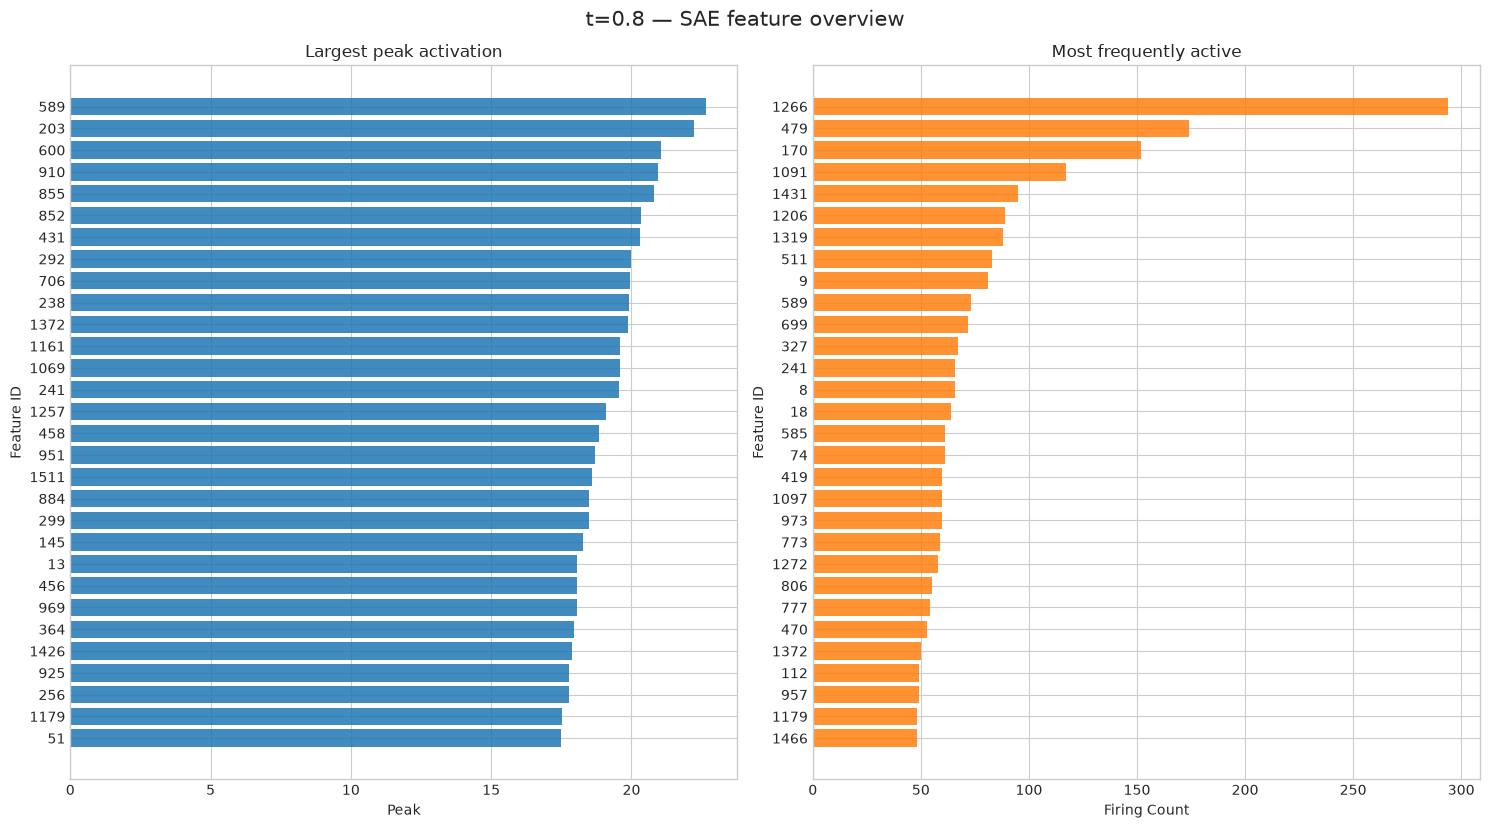

,feature,density,firing_count,mean_when_active,peak,decoder_norm,dead
0,589,0.073,73,6.430991,22.645657,1.0,False
1,203,0.023,23,11.365871,22.212818,1.0,False
2,600,0.008,8,14.564075,21.058550,1.0,False
3,910,0.012,12,13.023440,20.933510,1.0,False
4,855,0.006,6,14.877664,20.797264,1.0,False
5,852,0.013,13,7.181071,20.354460,1.0,False
6,431,0.007,7,10.902118,20.298204,1.0,False
7,292,0.009,9,15.217523,19.969894,1.0,False
8,706,0.012,12,9.027074,19.934568,1.0,False
9,238,0.011,11,5.884024,19.897045,1.0,False


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(7, TOP_FEATURES * 0.28)))
for ax, column, title, color in [(axes[0], 'peak', 'Largest peak activation', 'tab:blue'),
                                  (axes[1], 'firing_count', 'Most frequently active', 'tab:orange')]:
    ranked = feature_summary.nlargest(TOP_FEATURES, column).sort_values(column)
    ax.barh(ranked['feature'].astype(str), ranked[column], color=color, alpha=.85)
    ax.set(title=title, xlabel=column.replace('_', ' ').title(), ylabel='Feature ID')
fig.suptitle(f'{MODEL_LABEL} — SAE feature overview', fontsize=15)
fig.tight_layout(); plt.show()
display(feature_summary.nlargest(TOP_FEATURES, 'peak').reset_index(drop=True))

## Inspect one feature

The enrichment table compares scenario-type share among scenes where the feature fires with that type's share in the full dataset. Enrichment above 1 suggests selectivity; interpret small support cautiously.

Feature 589 | fires in 73/1,000 scenes (7.30%) | peak=22.646


,activation,scene_type,scene,simulation_id,map_name,actual_t,file
0,22.645657,stationary,7ebcc713c4b25ce6,a85d0cf18cb8,us-nv-las-vegas-strip,0.785564,a85d0cf18cb8.pt
1,22.267256,stationary,cc992689f1ea59d4,ae27e3804317,us-nv-las-vegas-strip,0.785564,ae27e3804317.pt
2,18.603394,stationary,bbd9a7725ac2550b,a2d3ddb58660,us-nv-las-vegas-strip,0.785564,a2d3ddb58660.pt
3,18.316795,stationary,e24edde71497529a,c0718c2c8146,us-nv-las-vegas-strip,0.785564,c0718c2c8146.pt
4,18.241367,stationary,36acc8ca941b58e7,678e996b5fbf,us-nv-las-vegas-strip,0.785564,678e996b5fbf.pt
5,17.701714,stationary,2bc480cc38785938,b3acb72d2338,us-nv-las-vegas-strip,0.785564,b3acb72d2338.pt
6,17.695133,stationary,443ccd6b775b55e2,01c4a6fc7a62,us-nv-las-vegas-strip,0.785564,01c4a6fc7a62.pt
7,15.440607,stationary,c44fbd408e825e81,59cee6899921,us-nv-las-vegas-strip,0.785564,59cee6899921.pt
8,14.690102,stationary,61bc0211abfb55c6,5c8ee7cc0e80,us-nv-las-vegas-strip,0.785564,5c8ee7cc0e80.pt
9,14.661390,stationary,3f99b87186055afa,70e7dd2e43bd,us-nv-las-vegas-strip,0.785564,70e7dd2e43bd.pt


,active_scenes,dataset_share,active_share,enrichment
scene_type,,,,
stationary,37.0,0.198,0.506849,2.559845
on_pickup_dropoff,3.0,0.020,0.041096,2.054795
stationary_in_traffic,21.0,0.204,0.287671,1.410153
traversing_pickup_dropoff,10.0,0.100,0.136986,1.369863
on_stopline_stop_sign,1.0,0.023,0.013699,0.595593
low_magnitude_speed,1.0,0.035,0.013699,0.391389
medium_magnitude_speed,0.0,0.121,0.000000,0.000000
traversing_traffic_light_intersection,0.0,0.104,0.000000,0.000000
traversing_intersection,0.0,0.060,0.000000,0.000000


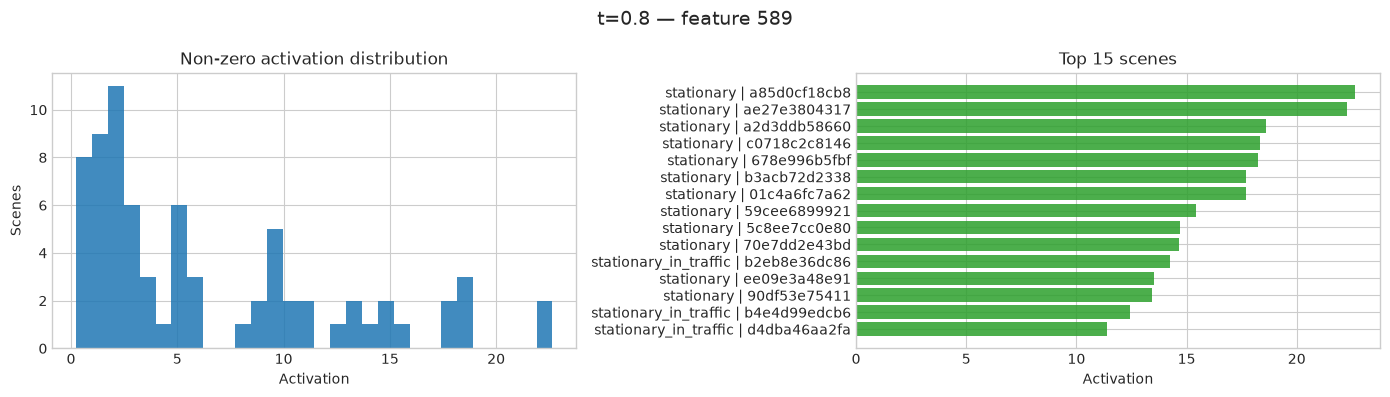

In [ ]:
def inspect_feature(feature_id, top_n=TOP_SCENES):
    if not 0 <= feature_id < feature_acts.shape[1]:
        raise IndexError(f'feature_id must be in [0, {feature_acts.shape[1] - 1}]')
    values = feature_acts[:, feature_id].numpy()
    active = values > 0
    result = metadata.copy()
    result['activation'] = values
    result = result.sort_values('activation', ascending=False)
    print(f'Feature {feature_id} | fires in {active.sum():,}/{len(active):,} scenes ({active.mean():.2%}) | peak={values.max():.3f}')
    display(result.head(top_n)[['activation', 'scene_type', 'scene', 'simulation_id', 'map_name', 'actual_t', 'file']].reset_index(drop=True))
    baseline = metadata['scene_type'].value_counts(normalize=True).rename('dataset_share')
    if active.any():
        counts = metadata.loc[active, 'scene_type'].value_counts()
        enrichment = pd.concat([counts.rename('active_scenes'), baseline], axis=1).fillna(0)
        enrichment['active_share'] = enrichment['active_scenes'] / active.sum()
        enrichment['enrichment'] = enrichment['active_share'] / enrichment['dataset_share']
        enrichment = enrichment.sort_values(['enrichment', 'active_scenes'], ascending=False)
        display(enrichment.head(15))
    else:
        enrichment = pd.DataFrame(); print('This feature is dead on the selected dataset.')
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    positive = values[active]
    if len(positive): axes[0].hist(positive, bins=min(30, max(5, len(positive))), color='tab:blue', alpha=.85)
    axes[0].set(title='Non-zero activation distribution', xlabel='Activation', ylabel='Scenes')
    top = result.head(top_n).sort_values('activation')
    labels = [
    f'{row.scene_type} | {str(row.scene)[:20]}'
    for row in top.itertuples()
    ]
    axes[1].barh(labels, top['activation'], color='tab:green', alpha=.85)
    axes[1].set(title=f'Top {min(top_n, len(result))} scenes', xlabel='Activation')
    fig.suptitle(f'{MODEL_LABEL} — feature {feature_id}', fontsize=14)
    fig.tight_layout(); plt.show()
    return result, enrichment

FEATURE_ID = int(feature_summary.loc[feature_summary['peak'].idxmax(), 'feature'])
top_scenes, type_enrichment = inspect_feature(FEATURE_ID)

## Compare several features across scenes

These heatmaps expose co-activation and scenario-type specialization. Change `FEATURE_IDS` to IDs found above. The first view is normalized per feature; the second shows raw SAE activation values.

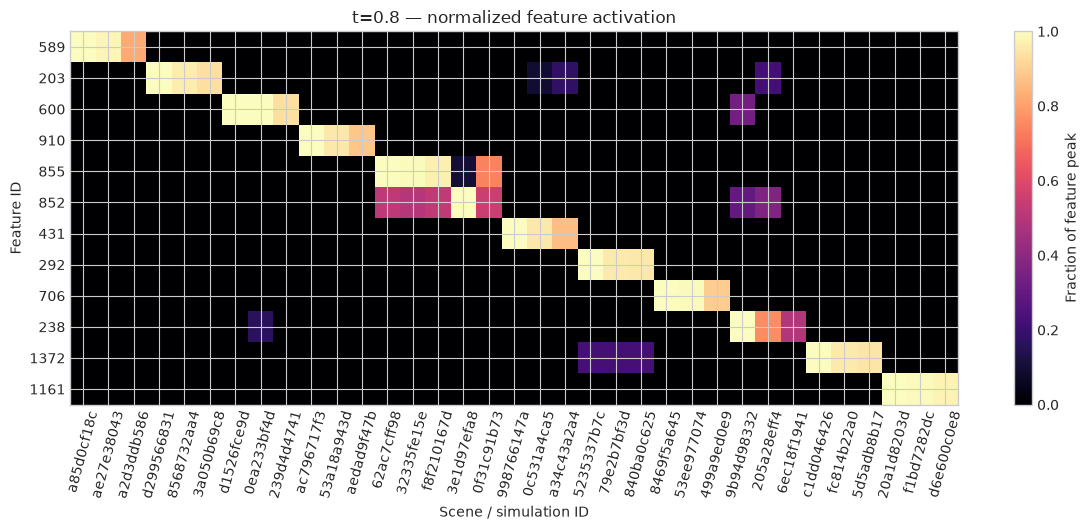

In [ ]:
FEATURE_IDS = feature_summary.nlargest(12, 'peak')['feature'].astype(int).tolist()
SCENES_PER_FEATURE = 3
scene_rows = []
for feature_id in FEATURE_IDS:
    scene_rows.extend(feature_acts[:, feature_id].topk(min(SCENES_PER_FEATURE, len(inputs))).indices.tolist())
scene_rows = list(dict.fromkeys(scene_rows))
raw_matrix = feature_acts[scene_rows][:, FEATURE_IDS].numpy()
normalized_matrix = raw_matrix / np.maximum(raw_matrix.max(axis=0, keepdims=True), 1e-12)
scene_type_labels = [str(metadata.iloc[i].scene_type) for i in scene_rows]

def plot_feature_heatmap(matrix, title, colorbar_label, vmax=None):
    fig, ax = plt.subplots(figsize=(max(8, len(FEATURE_IDS) * .7), max(6, len(scene_rows) * .35)))
    image = ax.imshow(matrix, aspect='auto', cmap='magma', vmin=0, vmax=vmax)
    ax.set_xticks(range(len(FEATURE_IDS)), [str(feature_id) for feature_id in FEATURE_IDS], rotation=45)
    ax.set_yticks(range(len(scene_rows)), scene_type_labels)
    ax.set(xlabel='Feature ID', ylabel='Scene type', title=title)
    fig.colorbar(image, ax=ax, label=colorbar_label)
    fig.tight_layout()
    plt.show()

plot_feature_heatmap(
    normalized_matrix,
    f'{MODEL_LABEL} — feature activation normalized per feature',
    'Fraction of feature peak',
    vmax=1,
)
plot_feature_heatmap(
    raw_matrix,
    f'{MODEL_LABEL} — raw feature activation',
    'Raw SAE activation',
)

## Interpretation notes

- Inspect several top scenes per feature; a single maximum can be an outlier.
- Use enrichment together with `active_scenes` support. High enrichment with one example is weak evidence.
- Change `MODEL_LABEL` and rerun to inspect another timestep. Feature IDs are not aligned across independently trained SAEs.
- The activation files contain scene metadata but no camera/raster images, so this notebook identifies scene IDs and types rather than rendering the road scene.